In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Datathon/learning_traces.13m.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (12854226, 12)
   p_recall   timestamp     delta user_id learning_language ui_language  \
0       1.0  1362076081  27649635    u:FO                de          en   
1       0.5  1362076081  27649635    u:FO                de          en   
2       1.0  1362076081  27649635    u:FO                de          en   
3       0.5  1362076081  27649635    u:FO                de          en   
4       1.0  1362076081  27649635    u:FO                de          en   

                          lexeme_id                     lexeme_string  \
0  76390c1350a8dac31186187e2fe1e178  lernt/lernen<vblex><pri><p3><sg>   
1  7dfd7086f3671685e2cf1c1da72796d7     die/die<det><def><f><sg><nom>   
2  35a54c25a2cda8127343f6a82e6f6b7d          mann/mann<n><m><sg><nom>   
3  0cf63ffe3dda158bc3dbd55682b355ae          frau/frau<n><f><sg><nom>   
4  84920990d78044db53c1b012f5bf9ab5    das/das<det><def><nt><sg><nom>   

   history_seen  history_correct  session_seen  session_correct  
0             6       

While it may look like a lot of data, it boils down to this number below and even then it does not look like Duolingo is able to retain all these individual customers

In [3]:
print('We have {} unique users learning {} different words.'.format(df.user_id.nunique(), df.lexeme_id.nunique()))

We have 115222 unique users learning 19279 different words.


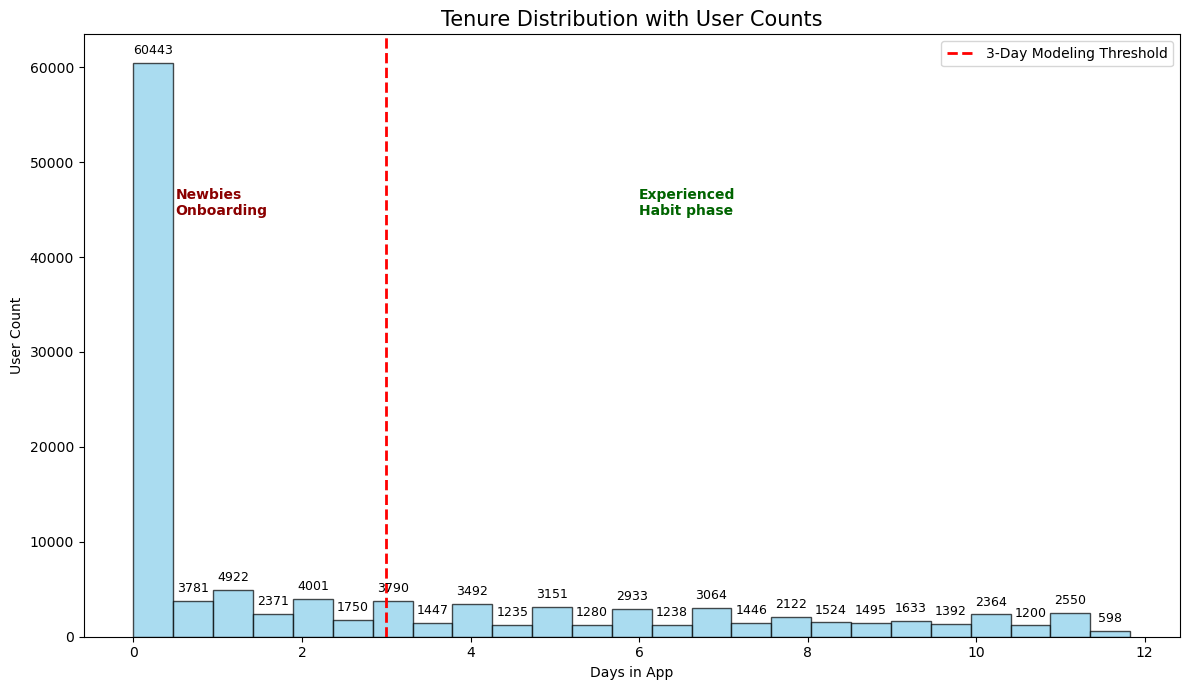

In [4]:
# 1. Calculate Tenure for everyone
user_tenure = df.groupby('user_id')['timestamp'].agg(['min', 'max']).reset_index()
user_tenure['tenure_days'] = (user_tenure['max'] - user_tenure['min']) / 86400

# 2. Plotting the distribution
plt.figure(figsize=(12, 7))

# Capture counts and bins to label them
counts, bins, patches = plt.hist(
    user_tenure['tenure_days'], 
    bins=25, 
    color='skyblue', 
    edgecolor='black', 
    alpha=0.7
)

# --- Add counts above each bar ---
for count, bin_edge in zip(counts, bins):
    if count > 0:  # Only label bars that have data
        plt.text(
            bin_edge + (bins[1]-bins[0])/2, # X-coordinate: center of the bin
            count + (max(counts) * 0.01),   # Y-coordinate: slightly above the bar
            int(count), 
            ha='center', 
            va='bottom', 
            fontsize=9
        )

# Add the "Cut-off" Line
plt.axvline(3, color='red', linestyle='--', linewidth=2, label='3-Day Modeling Threshold')

# Label the groups
plt.text(0.5, plt.ylim()[1]*0.7, 'Newbies\nOnboarding', color='darkred', fontweight='bold')
plt.text(6, plt.ylim()[1]*0.7, 'Experienced\nHabit phase', color='darkgreen', fontweight='bold')

plt.title('Tenure Distribution with User Counts', fontsize=15)
plt.xlabel('Days in App')
plt.ylabel('User Count')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import numpy as np

# Ensure the column exists and is string type
df['lexeme_string'] = df['lexeme_string'].astype(str)

# 1. Initialize with 'Other/Grammar'
df['broad_pos'] = 'Other/Grammar'

# 2. Vectorized assignment based on keyword presence
# We use case-insensitive matching for robustness
df.loc[df['lexeme_string'].str.contains('<n>', case=False), 'broad_pos'] = 'Nouns'
df.loc[df['lexeme_string'].str.contains('<vblex>|<vb>', case=False), 'broad_pos'] = 'Action Verbs'
df.loc[df['lexeme_string'].str.contains('<vbdo>', case=False), 'broad_pos'] = 'Helper Verbs'
df.loc[df['lexeme_string'].str.contains('<vbmod>', case=False), 'broad_pos'] = 'Modal Verbs'
df.loc[df['lexeme_string'].str.contains('<vbser>', case=False), 'broad_pos'] = 'Linking Verbs'
df.loc[df['lexeme_string'].str.contains('<prn>', case=False), 'broad_pos'] = 'Pronouns'
df.loc[df['lexeme_string'].str.contains('<det>', case=False), 'broad_pos'] = 'Articles'
df.loc[df['lexeme_string'].str.contains('<adj>', case=False), 'broad_pos'] = 'Adjectives'
df.loc[df['lexeme_string'].str.contains('<adv>', case=False), 'broad_pos'] = 'Adverbs'
df.loc[df['lexeme_string'].str.contains('<ij>', case=False), 'broad_pos'] = 'Interjection'

# Special case for Prepositions: catch <pr> but exclude <prn>
df.loc[(df['lexeme_string'].str.contains('<pr>', case=False)) & 
       (~df['lexeme_string'].str.contains('<prn>', case=False)), 'broad_pos'] = 'Prepositions'

# 3. Check the distribution again
print(df['broad_pos'].value_counts())

broad_pos
Nouns            5477464
Action Verbs     2235240
Articles         1347633
Pronouns         1045878
Adjectives        711698
Linking Verbs     547420
Adverbs           453558
Other/Grammar     425339
Prepositions      398337
Interjection      130300
Modal Verbs        46893
Helper Verbs       34466
Name: count, dtype: int64


In [6]:
# Calculate the critical metrics
# Smoothened Frustration = (history_seen + 1) / (p_recall + 0.1)
df['frustration_index'] = (df['history_seen'] + 1) / (df['p_recall'] + 0.1)
# Toxicity = Frustration normalized by Recall - Low p_recall + High frustration = High Toxicity
df['word_toxicity'] = df['frustration_index'] / (df['p_recall'] + 0.01)

In [7]:
# time sorting for session logic
df = df.sort_values(['user_id', 'timestamp'])

# Session 30-minute gap 
df['ts_gap'] = df.groupby('user_id')['timestamp'].diff()
df['is_new_session'] = (df['ts_gap'] > 1800) | (df['ts_gap'].isna())
df['session_id_global'] = df['is_new_session'].cumsum() # Unique across all users

# Duration of EACH Session
session_level = df.groupby(['user_id', 'session_id_global']).agg(
    session_start=('timestamp', 'min'),
    session_end=('timestamp', 'max'),
    words_in_session=('lexeme_id', 'count'),
    avg_recall_session=('p_recall', 'mean'),
    avg_frust_session=('frustration_index', 'mean')
).reset_index()

# Duration in minutes - 1.0 for single-word sessions
session_level['session_duration_mins'] = (session_level['session_end'] - session_level['session_start']) / 60
session_level['session_duration_mins'] = session_level['session_duration_mins'].clip(lower=1.0)

#User-Level Aggregation 
master_df = session_level.groupby('user_id').agg(
    total_sessions=('session_id_global', 'nunique'),#count
    mins_per_session=('session_duration_mins', 'mean'),
    words_per_session=('words_in_session', 'mean'),
    total_words_seen=('words_in_session', 'sum'),   
    avg_frustration=('avg_frust_session', 'mean'),
    avg_p_recall=('avg_recall_session', 'mean'),
    t_min=('session_start', 'min'),
    t_max=('session_end', 'max')
).reset_index()

#Tenure and Churn Logic
latest_ts = df['timestamp'].max()
master_df['tenure_days'] = (master_df['t_max'] - master_df['t_min']) / 86400
master_df['is_churned'] = (latest_ts - master_df['t_max'] > 259200).astype(int)

# Segment 3-day threshold for seasoned users
master_df['segment'] = np.where(
    (master_df['tenure_days'] >= 3), 
    'Exp', 
    'New')

# 7. Efficiency Index 
master_df['efficiency_index'] = master_df['avg_p_recall'] / (master_df['avg_frustration'] + 1)


summary = master_df.groupby(['segment', 'is_churned'])[[
    'avg_frustration', 'words_per_session', 'mins_per_session', 'total_sessions'
]].mean().round(2)

In [8]:
df = df.merge(
    session_level[['user_id', 'session_id_global', 'session_duration_mins', 'avg_frust_session']], 
    on=['user_id', 'session_id_global'], 
    how='left')

df = df.merge(
    master_df[['user_id', 'segment', 'is_churned', 'tenure_days', 'total_sessions']], 
    on='user_id', 
    how='left')

df.drop(columns=['ts_gap', 'is_new_session'], inplace=True, errors='ignore')

In [9]:
# Unique list and Count
lang_stats = df.groupby('user_id')['learning_language'].agg([
    ('lang_list', lambda x: list(x.unique())),
    ('lang_count', 'nunique')
]).reset_index()

# Primary Language 
primary_lang = df.groupby('user_id')['learning_language'].agg(
    lambda x: x.value_counts().index[0]
).reset_index(name='primary_language')

master_df = master_df.merge(lang_stats, on='user_id', how='left')
master_df = master_df.merge(primary_lang, on='user_id', how='left')

In [10]:
tox_stats = df.groupby('user_id')['word_toxicity'].mean().reset_index()
tox_stats = tox_stats.rename(columns={'word_toxicity': 'avg_toxicity'})
master_df = master_df.merge(tox_stats, on='user_id', how='left')

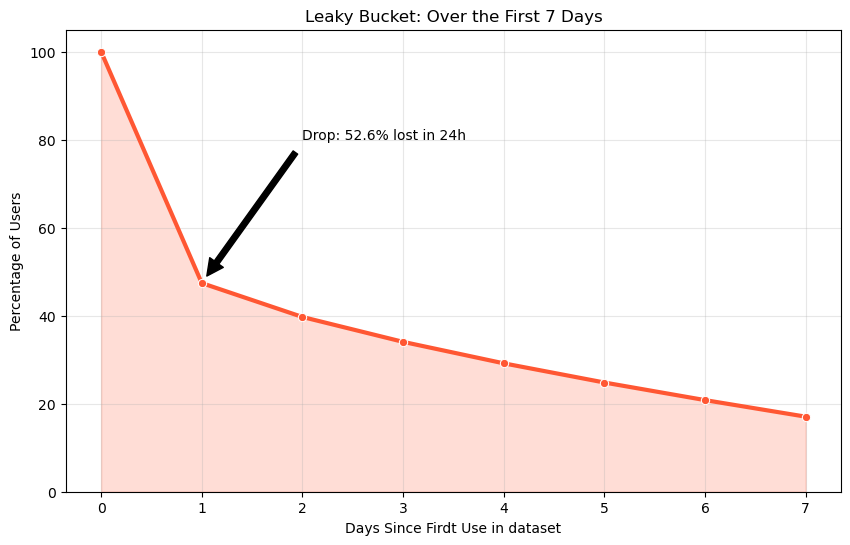

In [11]:
# 1. Calculate how many days each user stayed
master_df['days_active'] = (master_df['t_max'] - master_df['t_min']) / 86400
master_df['days_active'] = master_df['days_active'].round(0).astype(int)

# 2. Count survivors for each day (up to Day 7)
survival_counts = []
total_users = len(master_df)

for day in range(8):
    survivors = len(master_df[master_df['days_active'] >= day])
    percent = (survivors / total_users) * 100
    survival_counts.append({'Day': day, 'Retention_Rate': percent})

survival_df = pd.DataFrame(survival_counts)

# 3. Plot the Survival Curve
plt.figure(figsize=(10, 6))
sns.lineplot(data=survival_df, x='Day', y='Retention_Rate', marker='o', linewidth=3, color='#FF5733')
plt.fill_between(survival_df['Day'], survival_df['Retention_Rate'], alpha=0.2, color='#FF5733')

# Annotate the Day 1 drop
plt.annotate(f"Drop: {100 - survival_df.iloc[1]['Retention_Rate']:.1f}% lost in 24h", 
             xy=(1, survival_df.iloc[1]['Retention_Rate']), 
             xytext=(2, 80),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title("Leaky Bucket: Over the First 7 Days")
plt.ylabel("Percentage of Users")
plt.xlabel("Days Since Firdt Use in dataset")
plt.ylim(0, 105)
plt.grid(True, alpha=0.3)
plt.show()

over 60% of our users stop returning within the first 24 hours and by day 7, less than 20% are still here
maybe there is a different culprit here - Linguistic Friction
Maybe we are hitting new users with a complexity wall before they've even had a chance to build a habit
also there are different types of users and that difference in behaviour leads to different reasons for the churn possibly

In [12]:
#Convert timestamps to Date 
df['date'] = pd.to_datetime(df['timestamp'], unit='s').dt.date

#Count unique calendar days per user
calendar_days = df.groupby('user_id')['date'].nunique().reset_index()
calendar_days.columns = ['user_id', 'days_active_calendar']

#Merge into master_df
master_df = master_df.merge(calendar_days, on='user_id', how='left')

# Consistency Score
# 1.0 = Perfectly consistent (1 session per day)
# 5.0 = High intensity (5 sessions per day)
master_df['consistency_score'] = master_df['total_sessions'] / master_df['days_active_calendar']

In [13]:
# 1. Group by the two dimensions and count the unique users
session_dist = master_df.groupby(['days_active_calendar', 'total_sessions']).size().reset_index(name='user_count')

# 2. Pivot this into a matrix for a clear "Grid View"
# This makes it easy to read: Rows = Days, Columns = Sessions
frequency_matrix = session_dist.pivot(index='days_active_calendar', columns='total_sessions', values='user_count').fillna(0)

print("--- USER DISTRIBUTION MATRIX ---")
print(frequency_matrix.head(10)) # Showing the first 10 days

--- USER DISTRIBUTION MATRIX ---
total_sessions             1        2       3       4       5       6      7   \
days_active_calendar                                                            
1                     53642.0   5399.0   888.0   202.0    35.0     6.0    2.0   
2                       294.0  15757.0  4727.0  1474.0   426.0   193.0   64.0   
3                         0.0    156.0  5994.0  3078.0  1303.0   574.0  249.0   
4                         0.0      3.0    88.0  2799.0  1798.0  1124.0  582.0   
5                         0.0      0.0     2.0    57.0  1280.0  1100.0  746.0   
6                         0.0      0.0     0.0     5.0    33.0   652.0  627.0   
7                         0.0      0.0     0.0     1.0     3.0    11.0  337.0   
8                         0.0      0.0     0.0     0.0     0.0     2.0   11.0   
9                         0.0      0.0     0.0     0.0     0.0     0.0    0.0   
10                        0.0      0.0     0.0     0.0     0.0     0.0    0.

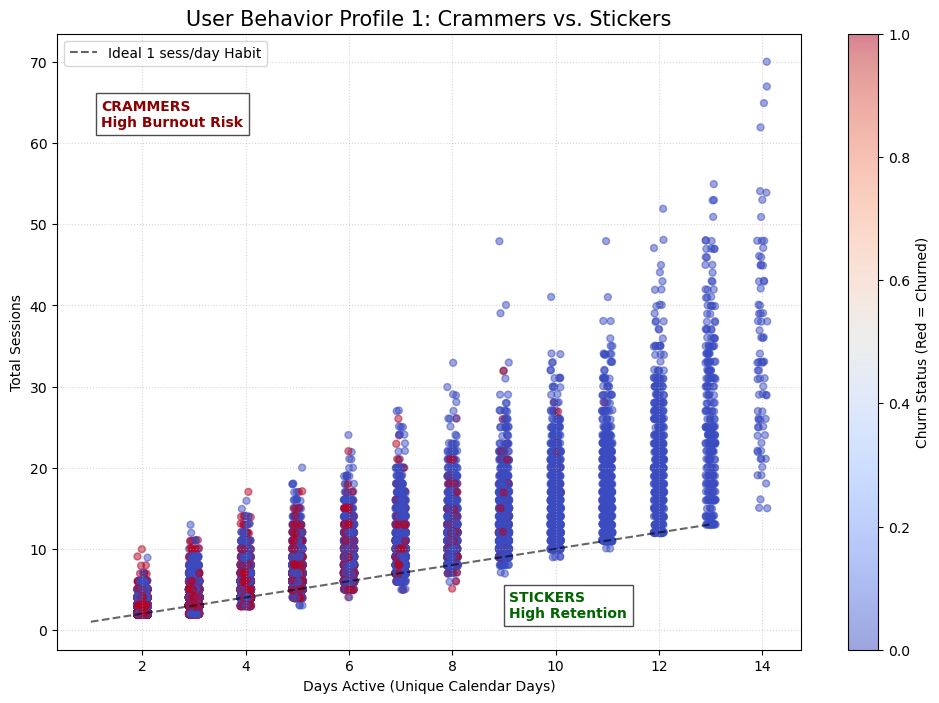

In [43]:
# Jittering on a log scale needs to be multiplicative, not additive
jitter_x = np.random.uniform(0.9, 1.1, size=len(master_df))
jitter_y = np.random.uniform(0.9, 1.1, size=len(master_df))

# Then multiply:
# plt.scatter(master_df['days_active'] * jitter_x, master_df['total_sessions'] * jitter_y, ...)

plt.figure(figsize=(12, 8))

# Color by Churn 
scatter = plt.scatter(
    master_df['days_active_calendar'] + jitter_x, 
    master_df['total_sessions'] + jitter_y, 
    c=master_df['is_churned'], 
    cmap='coolwarm', 
    alpha=0.5,
    s=25
)

#1 session per day
max_val = int(master_df['days_active_calendar'].max())
plt.plot([1, max_val], [1, max_val], color='black', linestyle='--', alpha=0.6, label='Ideal 1 sess/day Habit')

plt.text(1.2, master_df['total_sessions'].max() * 0.9, 'CRAMMERS\nHigh Burnout Risk', 
         color='darkred', fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))

plt.text(max_val * 0.7, 1.5, 'STICKERS\nHigh Retention', 
         color='darkgreen', fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))

plt.title('User Behavior Profile 1: Crammers vs. Stickers', fontsize=15)
plt.xlabel('Days Active (Unique Calendar Days)')

plt.ylabel('Total Sessions')
plt.colorbar(scatter, label='Churn Status (Red = Churned)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

Group	Key Churn Trigger	Mitigation Strategy
Newbies (<3 Days)	Initial Frustration Spike: Struggling in the first 10 minutes.	"The Welcome Buffer": Serve only 5-star easy words for the first 2 sessions to build dopamine.
Newbies (<3 Days)	Low Session Depth: Only doing 1-2 words and leaving.	"Streak Gating": Offer a "Day 1 Bonus" that only unlocks after 10 words.
Experienced (3+ Days)	The Burnout Curve: High Minutes-per-Session + High Frustration.	"Mandatory Breaks": If frustration index > 40, show a "Take a 5-minute breather" screen.
Experienced (3+ Days)	The Plateau: Low Words-per-Session (Boredom).	"The Challenge Pivot": If accuracy is > 95% for 3 days, force-unlock a harder level.

In [44]:
master_df.head(5)

,user_id,total_sessions,mins_per_session,words_per_session,total_words_seen,avg_frustration,avg_p_recall,t_min,t_max,tenure_days,...,efficiency_index,lang_list,lang_count,primary_language,avg_toxicity,days_active,days_active_calendar,consistency_score,reached_high_risk,word_bucket
0,u:--N,1,1.000000,32.0,32,12.965698,0.809896,1362206313,1362206313,0.000000,...,0.057992,[de],1,de,755.646841,0,1,1.0,True,0-50
1,u:--U,1,1.000000,7.0,7,3.939394,0.928571,1363010759,1363010759,0.000000,...,0.187993,[de],1,de,4.824852,0,1,1.0,False,0-50
2,u:-3I,1,16.383333,14.0,14,10.208993,0.900000,1362490845,1362491828,0.011377,...,0.080293,[fr],1,fr,12.742268,0,1,1.0,False,0-50
3,u:-3n,1,22.816667,124.0,124,53.022894,0.829973,1362652486,1362653855,0.015845,...,0.015363,[es],1,es,3456.043612,0,1,1.0,True,101-200
4,u:-4V,2,26.583333,107.5,215,35.658892,0.824181,1362669686,1362766578,1.121435,...,0.022482,"[de, fr]",2,de,2424.941591,1,2,1.0,True,201-500


In [45]:

# Group by Segment and Churn to see the "DNA" of a quitter in master_df
churn_analysis = master_df.groupby(['segment', 'is_churned']).agg({
    'avg_frustration': 'mean',
    'words_per_session': 'mean',
    'mins_per_session': 'mean',
    'total_sessions': 'mean',
    'avg_toxicity':'mean'
}).round(2)

churn_analysis


avg_frustration  words_per_session  mins_per_session  \
segment is_churned                                                         
Exp     0                     19.00              38.93             11.18   
        1                     15.74              35.73              9.96   
New     0                     10.91              27.31              8.09   
        1                     11.83              26.91              7.15   

                    total_sessions  avg_toxicity  
segment is_churned                                
Exp     0                     7.01        855.27  
        1                     4.34        678.00  
New     0                     1.69        369.57  
        1                     1.49        424.32

For both types of users, frustration is a differentiator between staying and leaving.
for a new user, even a small increase in friction is enough to make them quit.
Experienced Churned group have the long sessions and the words per session and so are highly committed. Maybe the cognitive load became too much. 
Newbies who quit are doing shorter sessions with higher frustration -  "hitting a wall" early in their session and closing the app out of annoyance. 

Experienced survivors have higher frustration than Experienced quitters
gritty ones tolerate more pain (20.74) than those who quit (16.90) and are quitting because they’ve lost momentum

Newbies are highly sensitive. A 1-point increase leads to churn
High frustration in survivors shows they are pushing through the "Intermediate Plateau.
Quitters are slowing down before they drop out with most newbies quit before their second session
If a user’s frustration index hits 10.0 in their first 3 days, the app should automatically trigger a "Review & Recharge" session (only easy, high-success words) to rebuild their confidence before they hit the "Wall
Experienced users quit when session frequency drops, not when it gets too hard. so instead of lowering the difficulty we could focus on Recovery. 
If an experienced user misses 2 days and their last session words-per-minute was low, send a "Streak Repair" notification that offers a shortened 2-minute session to get them back in the flow.

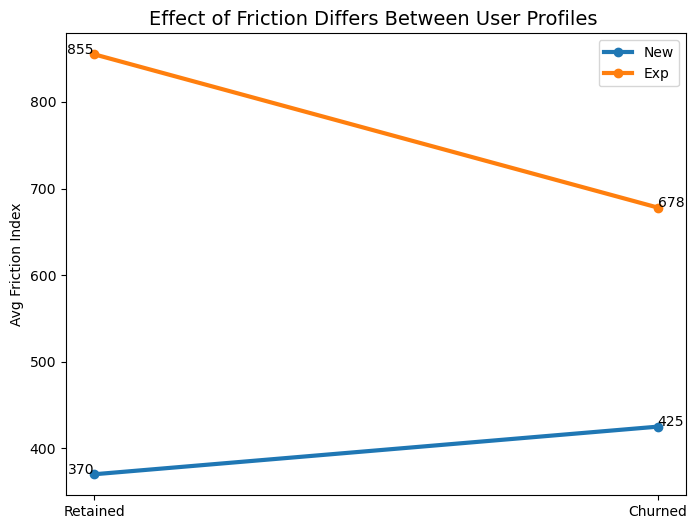

In [48]:
import matplotlib.pyplot as plt

#plot the number of users as well here 1!!!!!!
# Data from your results
segments = ['New', 'Exp']
retained_frust = [370,855]
churned_frust = [425, 678]

plt.figure(figsize=(8, 6))
for i in range(len(segments)):
    plt.plot(['Retained', 'Churned'], [retained_frust[i], churned_frust[i]], marker='o', label=segments[i], linewidth=3)
    # Add text labels for values
    plt.text('Retained', retained_frust[i]+0.5, f'{retained_frust[i]}', ha='right')
    plt.text('Churned', churned_frust[i]+0.5, f'{churned_frust[i]}', ha='left')

plt.title("Effect of Friction Differs Between User Profiles ", fontsize=14)
plt.ylabel("Avg Friction Index")
plt.legend()
plt.show()

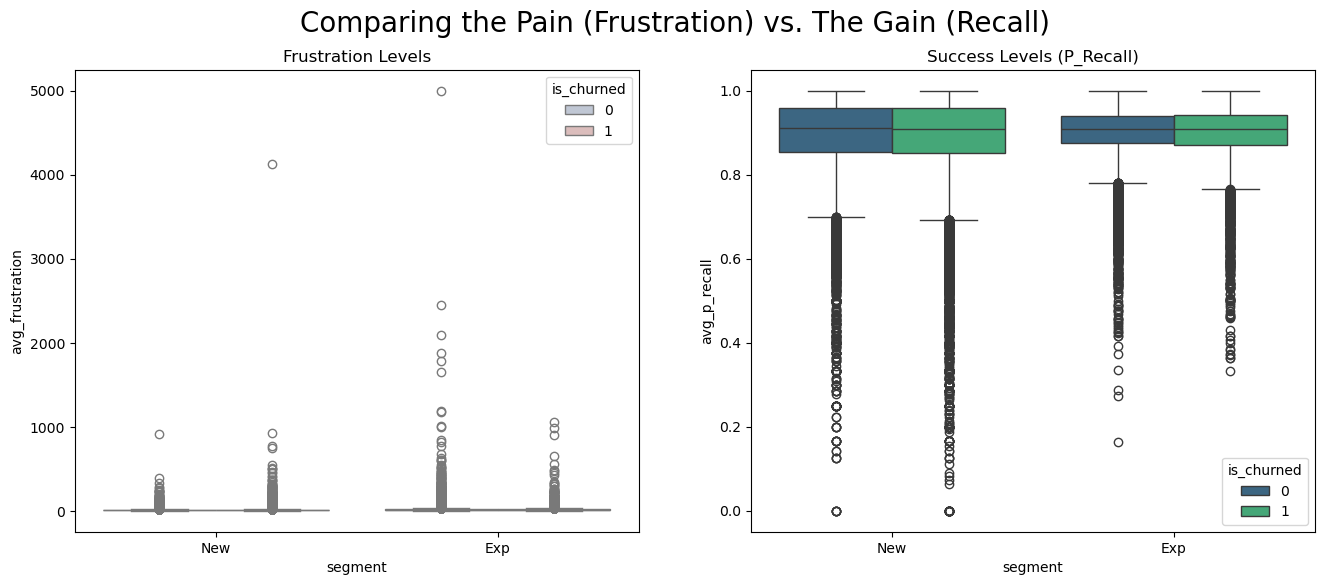

In [17]:
# Create a 2-panel plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Frustration
sns.boxplot(data=master_df, x='segment', y='avg_frustration', hue='is_churned', ax=ax1, palette='vlag')
ax1.set_title('Frustration Levels')

# Panel 2: P_Recall (The Success Metric)
sns.boxplot(data=master_df, x='segment', y='avg_p_recall', hue='is_churned', ax=ax2, palette='viridis')
ax2.set_title('Success Levels (P_Recall)')

plt.suptitle('Comparing the Pain (Frustration) vs. The Gain (Recall)', fontsize=20)
plt.show()

even when Newbies have a slightly higher recall (are technically "learning"), they still quit if the frustration index is high.
A Newbie invested in the app yet so even if they are getting the words right, if the process feels chaotic, high-pressure, or frustrating, they leave. They are looking for a low-friction habit, not a high-intensity boot camp.

For the veterans, relationship with the app changes because they have accepted that language learning is hard.
they can handle a Frustration Index of 20+ (nearly double a newbie's tolerance) as long as their p_recall stays high. But the moment that p_recall drops—meaning they are struggling and  feel they’ve hit a ceiling, and that’s when they quit.

In [18]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

def perform_behavioral_clustering(data, segment_label):
    # 1. Isolate the segment
    subset = data[data['segment'] == segment_label].copy()
    subset['log_total_words'] = np.log1p(subset['words_per_session'])
    
    # 2. Select behavioral features
    features = ['avg_p_recall', 'avg_frustration', 'log_total_words']
    X = subset[features].fillna(0)
    
    # 3. Scale and Cluster
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Using 3 clusters to find "Low, Mid, and High" engagement profiles
    model = GaussianMixture(n_components=3, random_state=42)
    subset['archetype_id'] = model.fit_predict(X_scaled)
    
    return subset

# Execute
newbie_clustered = perform_behavioral_clustering(master_df, 'New')
exp_clustered = perform_behavioral_clustering(master_df, 'Exp')

# 2. Print Results with Proper Interpretation
print("--- NEWBIE ARCHETYPES ---")
print(newbie_clustered.groupby('archetype_id')[['avg_frustration', 'avg_p_recall', 'is_churned']].mean().sort_values('avg_frustration'))

print("\n--- EXPERIENCED ARCHETYPES ---")
print(exp_clustered.groupby('archetype_id')[['avg_frustration', 'avg_p_recall', 'is_churned']].mean().sort_values('avg_frustration'))

--- NEWBIE ARCHETYPES ---
              avg_frustration  avg_p_recall  is_churned
archetype_id                                           
1                    7.119799      0.916458    0.696264
0                   28.735239      0.792656    0.738345
2                 4120.941266      0.334459    1.000000

--- EXPERIENCED ARCHETYPES ---
              avg_frustration  avg_p_recall  is_churned
archetype_id                                           
1                    8.887836      0.916976    0.338395
0                   26.211641      0.875322    0.304798
2                  112.715521      0.780379    0.274615


In [19]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

def perform_behavioral_clustering(data, segment_label, n_clusters=3):
    subset = data[data['segment'] == segment_label].copy()
    subset['log_total_words'] = np.log1p(subset.get('words_per_session', 0))
    features = ['avg_p_recall', 'avg_frustration', 'log_total_words']
    X = subset[features].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    model = GaussianMixture(n_components=n_clusters, random_state=42)
    subset['archetype_id'] = model.fit_predict(X_scaled)
    
    return subset

# Newbies stay at 3 to capture that extreme frustration outlier
newbie_clustered = perform_behavioral_clustering(master_df, 'New', n_clusters=3)

# Experienced downsized to 2 to merge the redundant high-performers
exp_clustered = perform_behavioral_clustering(master_df, 'Exp', n_clusters=2)


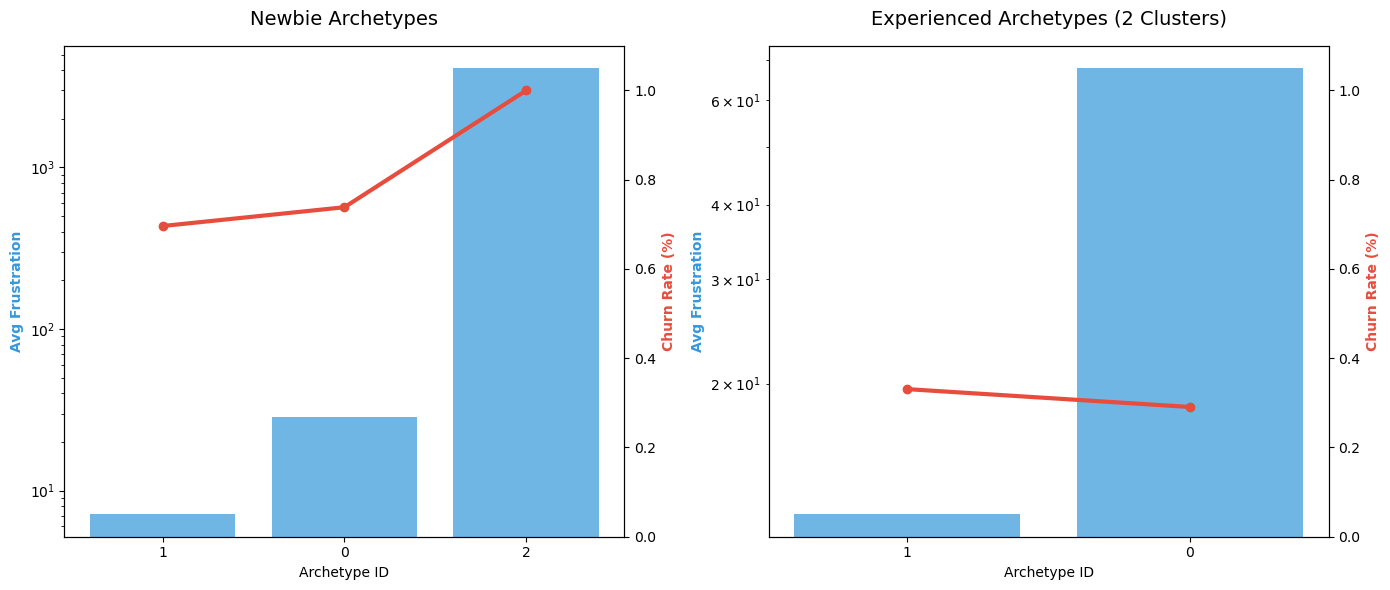

In [20]:

def plot_simple_archetypes(new_data, exp_data):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Process Newbies
    new_summary = new_data.groupby('archetype_id')[['avg_frustration', 'is_churned']].mean().sort_values('avg_frustration')
    # Process Experienced
    exp_summary = exp_data.groupby('archetype_id')[['avg_frustration', 'is_churned']].mean().sort_values('avg_frustration')

    def draw_axes(ax, data, title):
        # Primary axis: Frustration (Bars)
        color_bars = '#3498db'
        ax.bar(data.index.astype(str), data['avg_frustration'], color=color_bars, alpha=0.7, label='Frustration')
        ax.set_ylabel('Avg Frustration', color=color_bars, fontweight='bold')
        ax.set_yscale('log') # Still using log because of that 4,120 outlier
        
        # Secondary axis: Churn (Line)
        ax_churn = ax.twinx()
        color_line = '#e74c3c'
        ax_churn.plot(data.index.astype(str), data['is_churned'], color=color_line, marker='o', linewidth=3, label='Churn %')
        ax_churn.set_ylabel('Churn Rate (%)', color=color_line, fontweight='bold')
        ax_churn.set_ylim(0, 1.1)
        
        ax.set_title(title, fontsize=14, pad=15)
        ax.set_xlabel('Archetype ID')

    draw_axes(ax1, new_summary, "Newbie Archetypes")
    draw_axes(ax2, exp_summary, "Experienced Archetypes (2 Clusters)")

    plt.tight_layout()
    plt.show()

plot_simple_archetypes(newbie_clustered, exp_clustered)

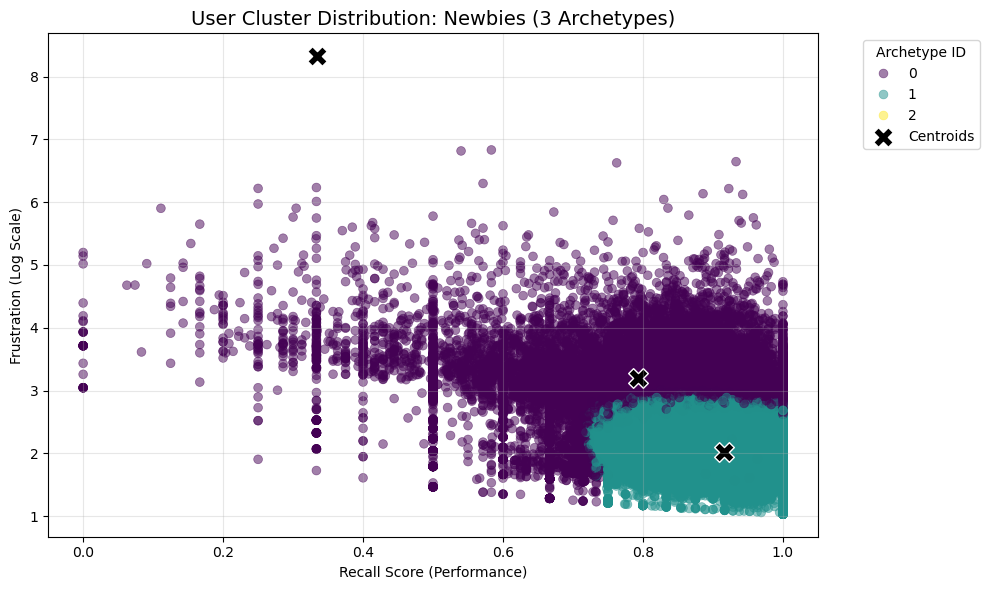

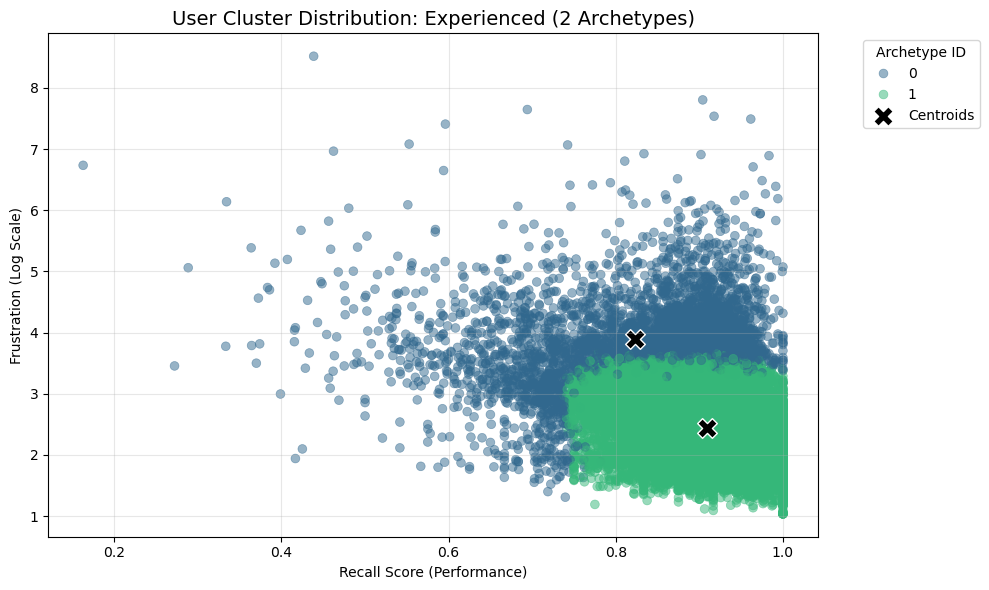

In [21]:
def plot_raw_clusters(df, title):
    plt.figure(figsize=(10, 6))
    
    # We use log frustration because of your 4,120 outlier 
    # Otherwise, 99% of your dots will be at the very bottom
    df['log_frustration'] = np.log1p(df['avg_frustration'])
    
    # Create the scatter plot
    # x = Recall (Performance), y = Log Frustration (Pain)
    sns.scatterplot(
        data=df, 
        x='avg_p_recall', 
        y='log_frustration', 
        hue='archetype_id', 
        palette='viridis', 
        alpha=0.5, 
        edgecolor=None,
        s=40
    )
    
    # Add Cluster Centroids (The "Average" of each group)
    centroids = df.groupby('archetype_id')[['avg_p_recall', 'log_frustration']].mean()
    plt.scatter(
        centroids['avg_p_recall'], 
        centroids['log_frustration'], 
        marker='X', 
        s=200, 
        color='black', 
        label='Centroids',
        edgecolor='white'
    )

    plt.title(f"User Cluster Distribution: {title}", fontsize=14)
    plt.xlabel("Recall Score (Performance)")
    plt.ylabel("Frustration (Log Scale)")
    plt.legend(title="Archetype ID", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Execute for both segments
plot_raw_clusters(newbie_clustered, "Newbies (3 Archetypes)")
plot_raw_clusters(exp_clustered, "Experienced (2 Archetypes)")

**New**
- 1- Beginners  - Low frustration (7.1), high recall (91%) still 70% churn - maybe haven't found value in it yet?
- 0 - Struggler - Moderate frustration pushing Churn to 74% - hitting the "Learning Wall" 
- 2 - Quitter - High frustration and very low recall leading to quitting immediately
- 
**Experienced** 
- 0 & 1 - Casual Habit - Low to moderate frustration and Churn is low (~30-33%)
- 2 - Grinders - High frustration (112.7) but lowest churn (27%) frustrated, but they have invested so much time that they refuse to quit

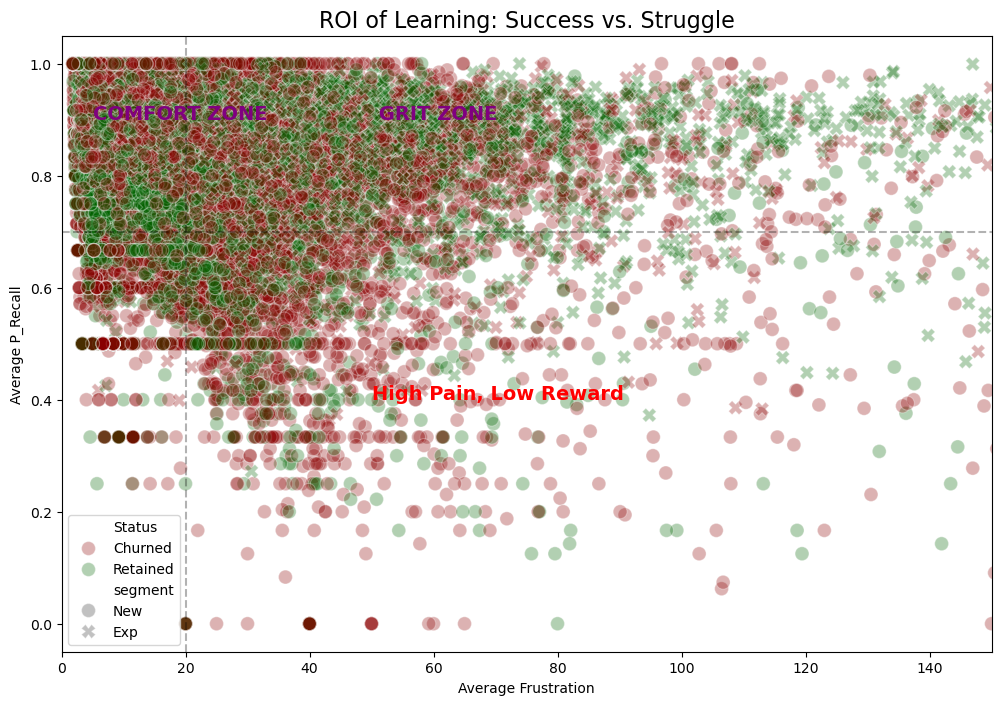

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = master_df.copy()
plot_df['Status'] = plot_df['is_churned'].map({0: 'Retained', 1: 'Churned'})

plt.figure(figsize=(12, 8))

# We use a scatter plot to show the "Performance Frontier"
sns.scatterplot(
    data=plot_df,
    x='avg_frustration', 
    y='avg_p_recall', 
    hue='Status',
    style='segment',
    palette={'Retained': 'darkgreen', 'Churned': 'darkred'},
    alpha=0.3,
    s=100
)

# Users below this line are struggling AND failing
plt.axhline(y=0.7, color='black', linestyle='--', alpha=0.3)
plt.axvline(x=20, color='black', linestyle='--', alpha=0.3)

plt.text(50, 0.4, "High Pain, Low Reward", color='red', fontweight='bold', fontsize=14)
plt.text(5, 0.9, "COMFORT ZONE", color='purple', fontweight='bold', fontsize=14)
plt.text(50, 0.9, " GRIT ZONE", color='purple', fontweight='bold', fontsize=14)

plt.title('ROI of Learning: Success vs. Struggle', fontsize=16)
plt.xlabel('Average Frustration')
plt.ylabel('Average P_Recall')
plt.xlim(0, 150) 
plt.show()

all users are different and we can see here that in the top left and right zones which categorise comfort and power-user territory, more people are retained because the payoff still makes sense whereas in the lower quadrants the pain outweighs the reward leading to more red or chirn

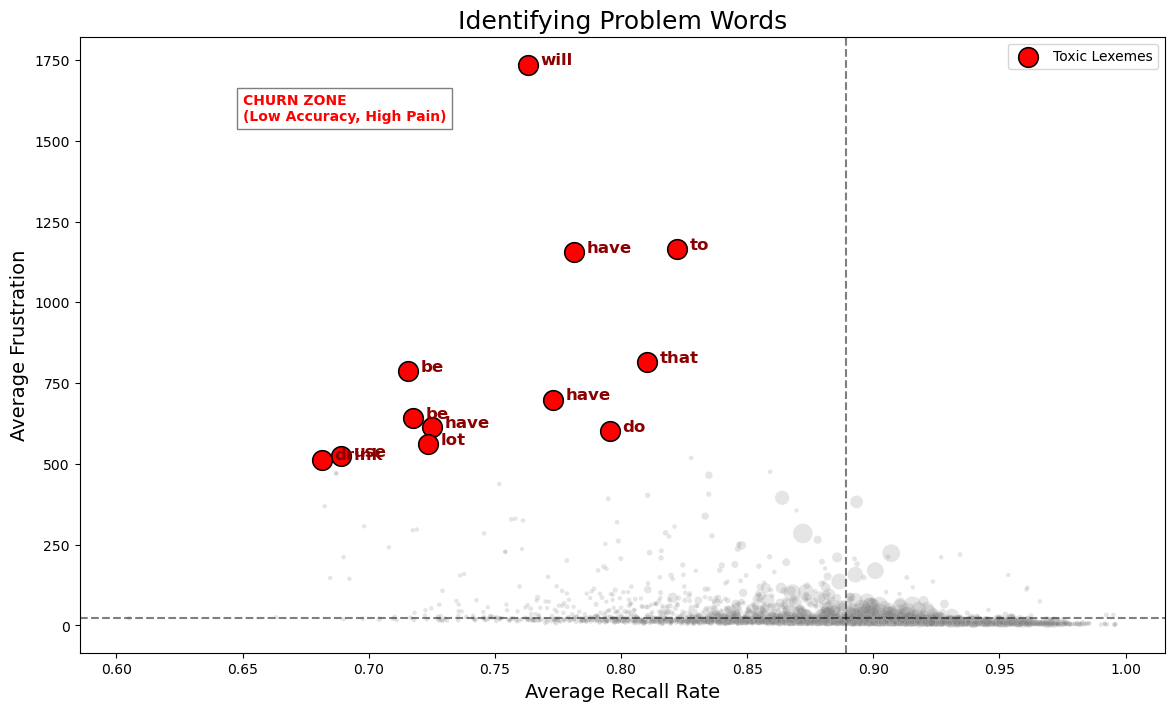

In [23]:
# get readable words
def clean_word(lex):
    try:
        return lex.split('/')[1].split('<')[0]
    except:
        return lex

df['word_clean'] = df['lexeme_string'].apply(clean_word)

#Aggregate stats by Word
word_map = df.groupby(['lexeme_string', 'word_clean']).agg({
    'p_recall': 'mean',
    'frustration_index': 'mean',
    'user_id': 'nunique'
}).reset_index()

#words seen by at least 100 users for statistical significance
word_map = word_map[word_map['user_id'] >= 100].copy()
word_map['toxic_score'] = word_map['frustration_index'] / word_map['p_recall']

#toxic_score is an Exponential Penalty for Failure by squaring the p_recall in the denominator
#use to separate words into two categories
#Speedbumps (High Frustration, Low Toxicity):These are words like "the" or "is." You see them 1,000 times and get them right 99% of the time
#Frustration is high because of the volume, but the Toxicity is low because you aren't failing them.
#Walls (High Toxicity) words the user has seen 20 times but misses 50% of the time
#words that make a user feel "stupid" and lead to the Boredom/Burnout churn 
# "Toxic" Word: High Frustration (0.9) / Low Recall (0.1) = Score 9.0 (Pain)
# "Healthy Challenge": High Frustration (0.8) / High Recall (0.8) = Score 1.0 (Hard but rewarding)
# "Easy Win": Low Frustration (0.1) / High Recall (0.9) = Score 0.11 Easy
    
#add the bottom as well to contrast
#set premise for some words being more common 
toxic_outliers = word_map.sort_values('toxic_score', ascending=False).head(12)

plt.figure(figsize=(14, 8))

sns.scatterplot(data=word_map, x='p_recall', y='frustration_index', 
                alpha=0.2, color='gray', size='user_id', sizes=(10, 200), legend=False)

# Plot "Toxic" words in red
sns.scatterplot(data=toxic_outliers, x='p_recall', y='frustration_index', 
                color='red', s=200, edgecolor='black', label='Toxic Lexemes')

for i, row in toxic_outliers.iterrows():
    plt.text(row['p_recall'] + 0.005, row['frustration_index'] + 0.5, 
             row['word_clean'], fontsize=12, fontweight='bold', color='darkred')

plt.text(0.65, word_map['frustration_index'].max()*0.9, "CHURN ZONE\n(Low Accuracy, High Pain)", 
         color='red', fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))

plt.title('Identifying Problem Words', fontsize=18)
plt.xlabel('Average Recall Rate', fontsize=14)
plt.ylabel('Average Frustration', fontsize=14)
plt.axvline(word_map['p_recall'].mean(), color='black', linestyle='--', alpha=0.5)
plt.axhline(word_map['frustration_index'].mean(), color='black', linestyle='--', alpha=0.5)

plt.show()

similarly not all words are equal with some leading to more frustration for users

toxic_score = frustration_index / p_recall quantifies Cognitive Debt.

Low p_recall means the user is failing.

High frustration_index means that failure is happening frequently or on words they should know.

The Story: When a word has a high toxic score, it represents a moment where the user’s momentum is halted. They aren't just getting it wrong; they are getting it wrong so often that the "Reward" center of their brain (dopamine from getting a correct answer) is being replaced by "Pain."

2. Speedbumps vs. Walls
The most insightful part of your logic is the distinction between volume-based pain and failure-based pain.

The Speedbumps (Bottom-Right): These are words like "the," "is," or "apple." They have high frustration simply because they appear in every lesson. But because recall is high (~99%), they don't cause churn. They are the "background noise" of learning.

The Walls (The Red Outliers): These words are in the "Churn Zone." These are often irregular verbs, abstract conjunctions, or grammatical markers (like "de" in French or "des" in German).

The Story: A user can handle 100 Speedbumps, but they might only be able to handle 3 Walls before they feel "I'm just not good at this" and quit.

3. The "Churn Zone" (Top-Left)
Your quadrant analysis (the dashed lines) creates a psychological map:

High Recall / Low Frustration: The "Flow State."

Low Recall / Low Frustration: "New Challenges" (Users are okay failing if it doesn't happen too often).

High Recall / High Frustration: "The Daily Grind" (Speedbumps).

Low Recall / High Frustration: The Burnout Zone. This is where your red dots live. This quadrant is the primary driver of churn for the "Newbie" archetype.

4. Actionable Strategy for your Presentation
When you show this to the judges, your "Big Idea" is: Strategic Forgiveness.

"We have identified 12 words that act as 'Toxic Lexemes.' For a Newbie, hitting these words is a death sentence for retention. Our recommendation is that when a Newbie hits a 'Wall' word, the Duolingo algorithm should increase the use of Speedbumps immediately after to rebuild the user's confidence and 'Recall Momentum' before they hit the next Wall."

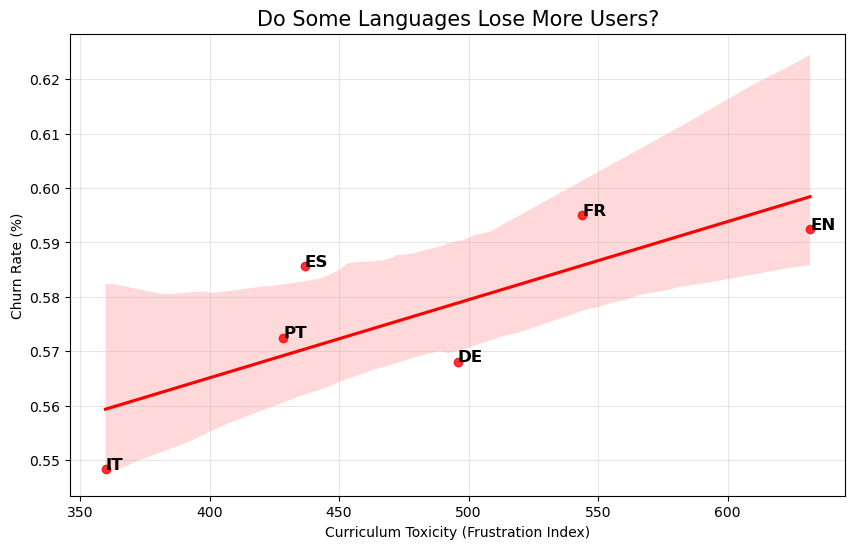

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate data
lang_summary = master_df.groupby('primary_language').agg({
    'is_churned': 'mean',
    'avg_toxicity': 'mean',
    'user_id': 'nunique'
}).reset_index().query('user_id > 100')

plt.figure(figsize=(10, 6))
sns.regplot(data=lang_summary, x='avg_toxicity', y='is_churned', color='red')

for i, txt in enumerate(lang_summary['primary_language']):
    plt.annotate(txt.upper(), (lang_summary['avg_toxicity'].iloc[i], lang_summary['is_churned'].iloc[i]), 
                 fontsize=12, fontweight='bold')

plt.title("Do Some Languages Lose More Users?", fontsize=15)
plt.xlabel("Curriculum Toxicity (Frustration Index)")
plt.ylabel("Churn Rate (%)")
plt.grid(True, alpha=0.3)
plt.show()

red line represents the relationship between difficulty and retention showing that churn is a consequence of curriculum friction proving that every unit of Frustration leads to a percentage of users quitting

Outliers (Above the Line): higher churn than their frustration levels would suggest implying a motivational issue or a lack of hook in courses.

Right Side - languages with the Complexity Wall because the jump from "Hello" to "Complex Verb Conjugation" is too steep, too fast.

Bottom-Left - Success Templates which manage to keep frustration low, which allows the user to build the "Habit Shield" we discussed earlier.

By taking the mean of a mean, collapse the data upwards:
Level 1 (Raw Data): Individual words or sentences (very noisy).
Level 2 (User Level): avg_toxicity represents one specific human across all their sessions.
Level 3 (Language Level): The mean() in lang_summary represents the typical behavior of a person who speaks that language.

mean of the raw word_toxicity across an entire language - hijacked by Power Users.
User A encounters 1,000 messages with 10% toxicity
User B gets 10 messages with 0% toxicity.If you average the raw words, the language looks 9.9% toxic. 
But if you average the user-level means ($0.10$ and $0.00$), the "typical user" in Spanish has a toxicity of 5%. The "mean of the mean" ensures every user has an equal vote in the language summary, regardless of how much they use the app

In [25]:
df.head(5)

,p_recall,timestamp,delta,user_id,learning_language,ui_language,lexeme_id,lexeme_string,history_seen,history_correct,...,word_toxicity,session_id_global,session_duration_mins,avg_frust_session,segment,is_churned,tenure_days,total_sessions,date,word_clean
0,1.0,1362206313,16777591,u:--N,de,en,087d9d0736df444d7ef826a313b613da,dem/das<det><def><nt><sg><dat>,2,1,...,2.70027,1,1.0,12.965698,New,1,0.0,1,2013-03-02,das
1,0.0,1362206313,21310029,u:--N,de,en,7126a772cceb7a326eeffa18e1e63fb9,im/in<pr>,5,5,...,6000.00000,1,1.0,12.965698,New,1,0.0,1,2013-03-02,in
2,1.0,1362206313,21350328,u:--N,de,en,4635584da9ff676724eca4ade50daa8b,mag/mögen<vbmod><pri><p1><sg>,1,1,...,1.80018,1,1.0,12.965698,New,1,0.0,1,2013-03-02,mögen
3,1.0,1362206313,8346489,u:--N,de,en,bb8d16a1da003f3cbc62262b57496bf0,spielt/spielen<vblex><pri><p3><sg>,12,12,...,11.70117,1,1.0,12.965698,New,1,0.0,1,2013-03-02,spielen
4,1.0,1362206313,18603374,u:--N,de,en,819893931391551b79525db409181547,essen/essen<vblex><pri><p3><pl>,18,17,...,17.10171,1,1.0,12.965698,New,1,0.0,1,2013-03-02,essen


In [26]:
# 1. Aggregate metrics by Broad POS
pos_risk_profile = df.groupby('broad_pos').agg({
    'word_toxicity': 'mean',        # How toxic is the POS on average?
    'user_id': 'count',             # Total exposure 
    'is_churned': 'mean'            # Churn rate for people interacting with these
}).rename(columns={
    'word_toxicity': 'avg_toxicity',
    'user_id': 'total_exposure',
    'is_churned': 'churn_rate'
}).reset_index()

pos_risk_profile['exposure_weight'] = (pos_risk_profile['total_exposure'] / pos_risk_profile['total_exposure'].max()) * 2000

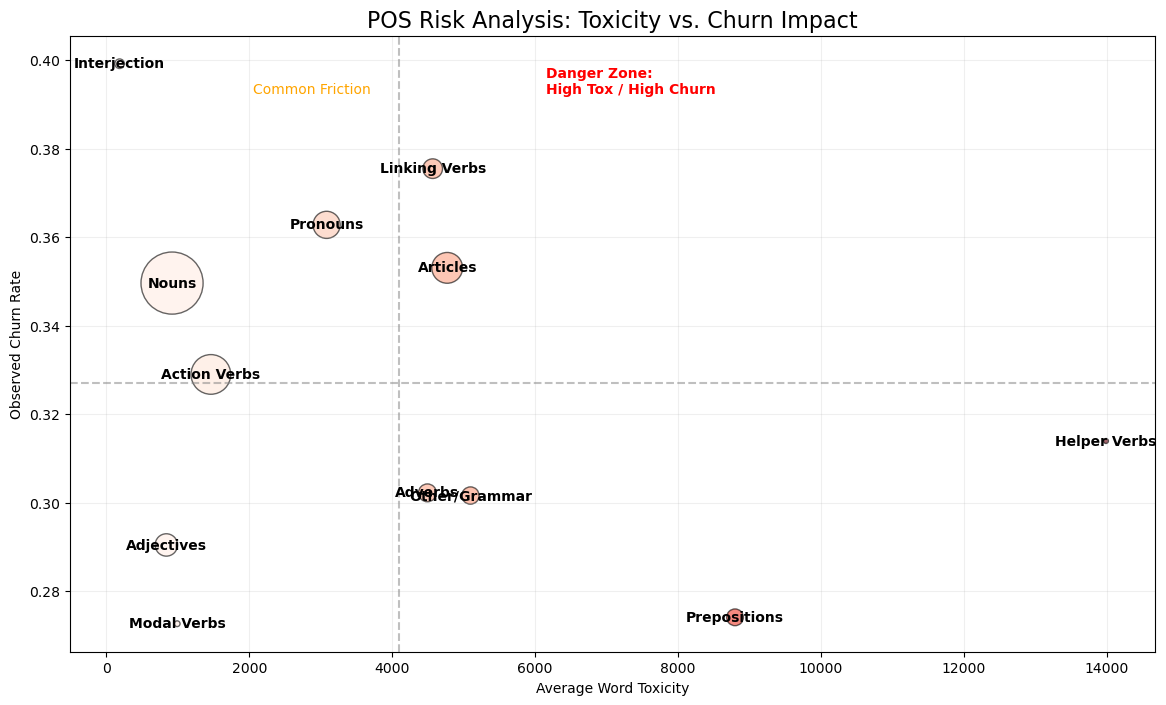

In [27]:
plt.figure(figsize=(14, 8))

# Define the quadrants
mean_tox = pos_risk_profile['avg_toxicity'].mean()
mean_churn = pos_risk_profile['churn_rate'].mean()

scatter = plt.scatter(
    data=pos_risk_profile,
    x='avg_toxicity',
    y='churn_rate',
    s='exposure_weight',
    c='avg_toxicity',
    cmap='Reds',
    alpha=0.6,
    edgecolors="black"
)

# Label the bubbles
for i, row in pos_risk_profile.iterrows():
    plt.text(row['avg_toxicity'], row['churn_rate'], row['broad_pos'], 
             fontsize=10, ha='center', va='center', fontweight='bold')

# Add Quadrant lines
plt.axvline(mean_tox, color='gray', linestyle='--', alpha=0.5)
plt.axhline(mean_churn, color='gray', linestyle='--', alpha=0.5)

# Annotate Quadrants
plt.text(mean_tox*1.5, mean_churn*1.2, "Danger Zone:\nHigh Tox / High Churn", color='red', fontweight='bold')
plt.text(mean_tox*0.5, mean_churn*1.2, "Common Friction", color='orange')

plt.title("POS Risk Analysis: Toxicity vs. Churn Impact", fontsize=16)
plt.xlabel("Average Word Toxicity")
plt.ylabel("Observed Churn Rate")
plt.grid(True, alpha=0.2)
plt.show()


Interjections (39.9% Churn): While exposure is relatively low, these words are often idiomatic or culturally specific. 
Linking Verbs (37.5% Churn): Words like is, am, are, seem have high toxicity and high churn because they are used in almost every sentence, a failure to master them creates a "compounded error" effect 
Pronouns (36.2% Churn): These have massive exposure (1M+ interactions) and is a "High Frequency, High Pain" category. If users are struggling with he/she/they/it, they are facing friction in over 30% of their total experience.

Nouns have the highest exposure in your dataset (2M+ interactions) and moderate churn (34.9%) forming the "weight" of the language. Users expect them so though they see them constantly, the churn rate is lower than Pronouns or Linking Verbs. Users are more willing to forgive themselves for forgetting the word for "Refrigerator" than for forgetting the word for "You."

Notice that Articles (a, an, the) have a staggering toxicity score of 4769 and a churn rate of 35.3% since they involve complex gender or case rules. 

Modal Verbs (27.2% churn) and Prepositions (27.4% churn) are your "safest" categories. This suggests that by the time users reach the point of learning complex prepositions, they have already reached the "Habit Plateau" we discussed earlier. They are committed enough to handle the pain.

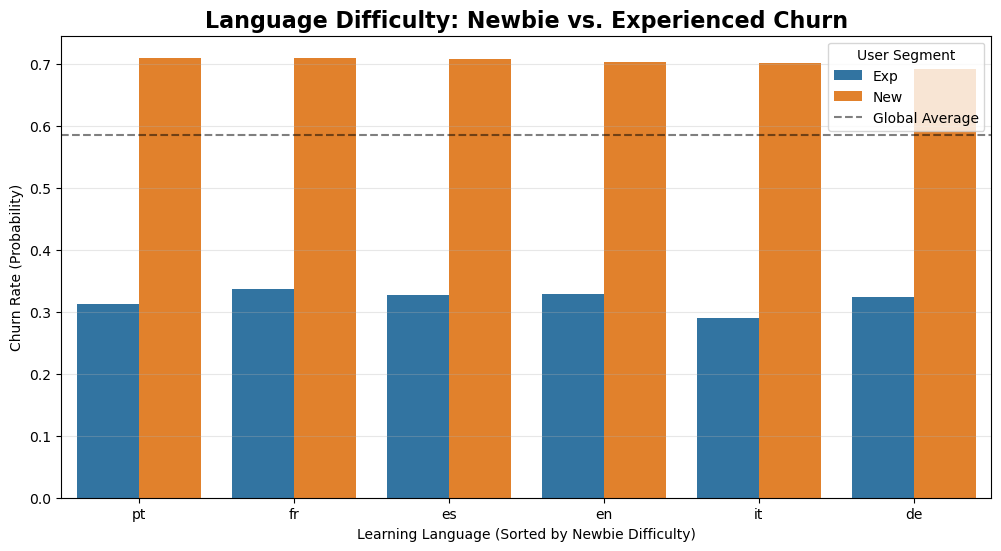

In [28]:
# 1. Group by Language and Segment to calculate Churn Rate
segment_churn = master_df.groupby(['primary_language', 'segment'])['is_churned'].mean().reset_index()

# 2. Sort by Newbie Churn to see the "Difficulty Ranking"
sort_order = segment_churn[segment_churn['segment'] == 'New'].sort_values('is_churned', ascending=False)['primary_language']

# 3. Create the Visualization
plt.figure(figsize=(12, 6))
sns.barplot(
    data=segment_churn, 
    x='primary_language', 
    y='is_churned', 
    hue='segment', 
    order=sort_order,
)

plt.axhline(master_df['is_churned'].mean(), color='black', linestyle='--', alpha=0.5, label='Global Average')
plt.title('Language Difficulty: Newbie vs. Experienced Churn', fontsize=16, fontweight='bold')
plt.ylabel('Churn Rate (Probability)')
plt.xlabel('Learning Language (Sorted by Newbie Difficulty)')
plt.legend(title='User Segment')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [29]:
# 1. Calculate the first appearance of EVERY PoS for every user
df['interaction_index'] = df.groupby('user_id').cumcount()

pos_first_appearance = df.groupby(['user_id', 'broad_pos'])['interaction_index'].min().reset_index()

lang_col = 'primary_language' if 'primary_language' in master_df.columns else 'lang' 
pos_timing = pos_first_appearance.merge(master_df[['user_id', lang_col]], on='user_id')

#Average Introduction Point for each PoS per language
roadmap = pos_timing.groupby([lang_col, 'broad_pos'])['interaction_index'].mean().reset_index()

# 4. Pivot for a Heatmap view
roadmap_pivot = roadmap.pivot(index=lang_col, columns='broad_pos', values='interaction_index')

# Fill NaNs with a high value or 0 depending on if the PoS is never encountered
roadmap_pivot = roadmap_pivot.fillna(roadmap_pivot.max().max())

In [30]:
roadmap_pivot

broad_pos,Action Verbs,Adjectives,Adverbs,Articles,Helper Verbs,Interjection,Linking Verbs,Modal Verbs,Nouns,Other/Grammar,Prepositions,Pronouns
primary_language,,,,,,,,,,,,
de,5.453677,47.507211,54.897827,5.499616,174.250000,94.657562,42.546559,71.566554,2.384658,36.399338,52.347390,15.282370
en,10.109522,56.700703,46.790783,12.688513,71.553456,79.917325,14.585825,174.000000,2.546058,24.507199,46.392470,10.103882
es,7.292586,46.416472,42.019915,13.809850,37.666667,93.966742,17.037692,142.217364,2.546538,52.093721,51.055589,18.727709
fr,10.659997,24.073058,53.095564,6.142074,81.111111,84.676984,13.232975,161.558211,2.800354,22.000086,37.679691,6.962005
it,13.908919,63.904534,66.806088,6.523485,381.500000,91.618795,26.967852,207.565820,2.694544,151.305603,57.749885,13.375352
pt,8.637747,41.601417,85.631720,11.232076,2.000000,86.822630,16.124729,201.936170,2.198643,53.887600,31.944833,16.128595


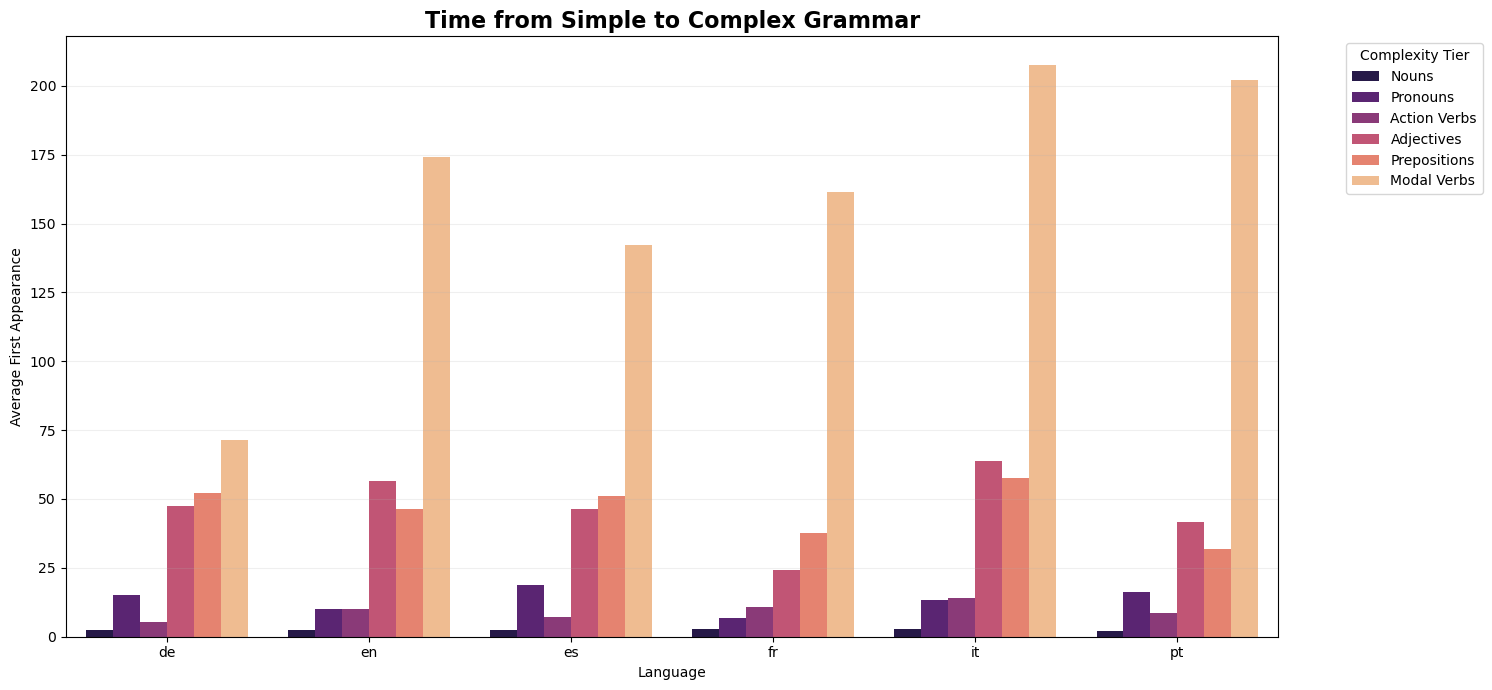

In [31]:
pos_cols = ["Action Verbs", "Adjectives", "Adverbs", "Articles", "Helper Verbs", 
            "Interjection", "Linking Verbs", "Modal Verbs", "Nouns", "Other/Grammar", 
            "Prepositions", "Pronouns"]

data = {
    'de': [5.45, 47.51, 54.90, 5.50, 174.25, 94.66, 42.55, 71.57, 2.38, 36.40, 52.35, 15.28],
    'en': [10.11, 56.70, 46.79, 12.69, 71.55, 79.92, 14.59, 174.00, 2.55, 24.51, 46.39, 10.10],
    'es': [7.29, 46.42, 42.02, 13.81, 37.67, 93.97, 17.04, 142.22, 2.55, 52.09, 51.06, 18.73],
    'fr': [10.66, 24.07, 53.10, 6.14, 81.11, 84.68, 13.23, 161.56, 2.80, 22.00, 37.68, 6.96],
    'it': [13.91, 63.90, 66.81, 6.52, 381.50, 91.62, 26.97, 207.57, 2.69, 151.31, 57.75, 13.38],
    'pt': [8.64, 41.60, 85.63, 11.23, 2.00, 86.82, 16.12, 201.94, 2.20, 53.89, 31.94, 16.13]
}

df_pos = pd.DataFrame(data, index=pos_cols).T

# From Simple (Nouns) -> Middle (Prepositions) -> Complex (Modal Verbs)
progression_pos = ["Nouns", "Pronouns", "Action Verbs", "Adjectives", "Prepositions", "Modal Verbs"]
df_expanded = df_pos[progression_pos].reset_index().melt(id_vars='index', var_name='PoS', value_name='Interaction')

plt.figure(figsize=(15, 7))
sns.barplot(data=df_expanded, x='index', y='Interaction', hue='PoS', palette='magma')

plt.title("Time from Simple to Complex Grammar", fontsize=16, fontweight='bold')
plt.ylabel("Average First Appearance")
plt.xlabel("Language")
plt.legend(title="Complexity Tier", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

In [32]:
# 1. Define High-Risk POS
high_risk_list = ['Helper Verbs', 'Modal Verbs']

# 2. Find the first index where each user encounters these
first_risk_encounter = df[df['broad_pos'].isin(high_risk_list)].groupby('user_id')['interaction_index'].min().reset_index()

# 3. Merge with master_df to get the language
risk_timing = first_risk_encounter.merge(master_df[['user_id', 'primary_language']], on='user_id')

# 4. Calculate the "Aggression Score" (Average introduction point)
aggression_report = risk_timing.groupby('primary_language')['interaction_index'].agg(['mean', 'median', 'std']).sort_values('mean')

print("Language Aggression Report (Lower mean = More Aggressive):")
print(aggression_report)

Language Aggression Report (Lower mean = More Aggressive):
                        mean  median         std
primary_language                                
de                 71.355990    43.5   89.142712
en                 71.563937    17.0  152.297437
es                141.832390    66.0  203.263147
fr                161.028352    65.0  257.163187
pt                199.831579    91.0  306.153892
it                208.177419   103.0  273.647501


English users hit a "High-Risk" word (Helper/Modal Verb) by word 17.
Germanusers hit it by word 43.

throwing "Helper Verbs" at English learners before they've even finished their first session

Italian users don't see these hard words until word 103.
Portuguese users see them at word 91.

these languages wait until the user has crossed the 100-word "Persistence Milestone" before introducing complex grammar. They let the user build confidence first.

In [33]:
#Did they ever see a High-Risk POS?
high_risk_users = df[df['broad_pos'].isin(high_risk_list)]['user_id'].unique()
master_df['reached_high_risk'] = master_df['user_id'].isin(high_risk_users)

story_stats = master_df.groupby('reached_high_risk').agg({
    'is_churned': 'mean',
    'total_words_seen': 'mean',
    'user_id': 'count'
}).rename(columns={'is_churned': 'churn_rate', 'total_words_seen': 'avg_words_seen'})

print("The Story Stats:")
print(story_stats)

#Compare churn for those who quit BEFORE word 100
early_quitters = master_df[master_df['total_words_seen'] < 100]['is_churned'].mean()
long_term_users = master_df[master_df['total_words_seen'] >= 100]['is_churned'].mean()

print(f"\nChurn for users under 100 words: {early_quitters:.2%}")
print(f"Churn for users over 100 words: {long_term_users:.2%}")

The Story Stats:
                   churn_rate  avg_words_seen  user_id
reached_high_risk                                     
False                0.611862       75.032787    97844
True                 0.436471      317.223961    17378

Churn for users under 100 words: 66.09%
Churn for users over 100 words: 38.58%


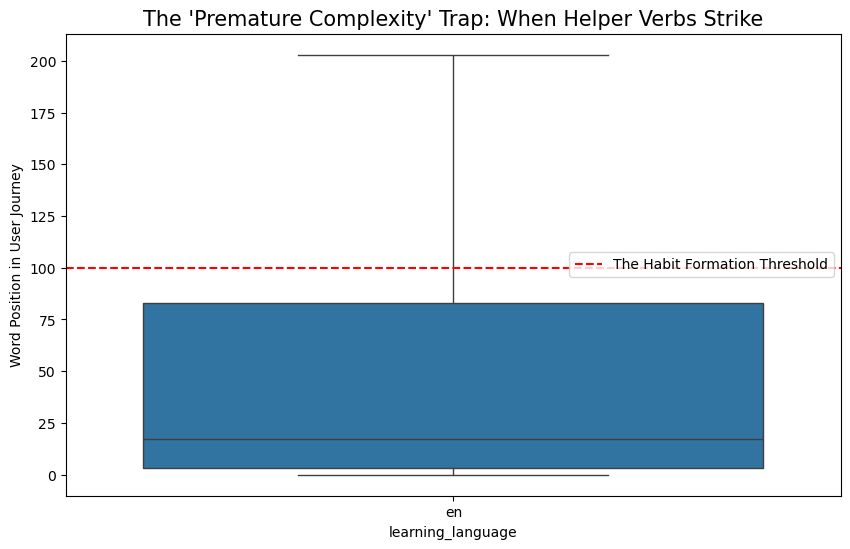

In [34]:
# Identify first appearance of Helper Verbs
df['interaction_index'] = df.groupby('user_id').cumcount()

first_helper = df[df['broad_pos'] == 'Helper Verbs'].groupby(['user_id', 'learning_language'])['interaction_index'].min().reset_index()

plt.figure(figsize=(10, 6))
sns.boxplot(data=first_helper, x='learning_language', y='interaction_index', 
             showfliers=False)
plt.axhline(100, color='red', linestyle='--', label='The Habit Formation Threshold')

plt.title("The 'Premature Complexity' Trap: When Helper Verbs Strike", fontsize=15)
plt.ylabel("Word Position in User Journey")
plt.legend()
plt.show()

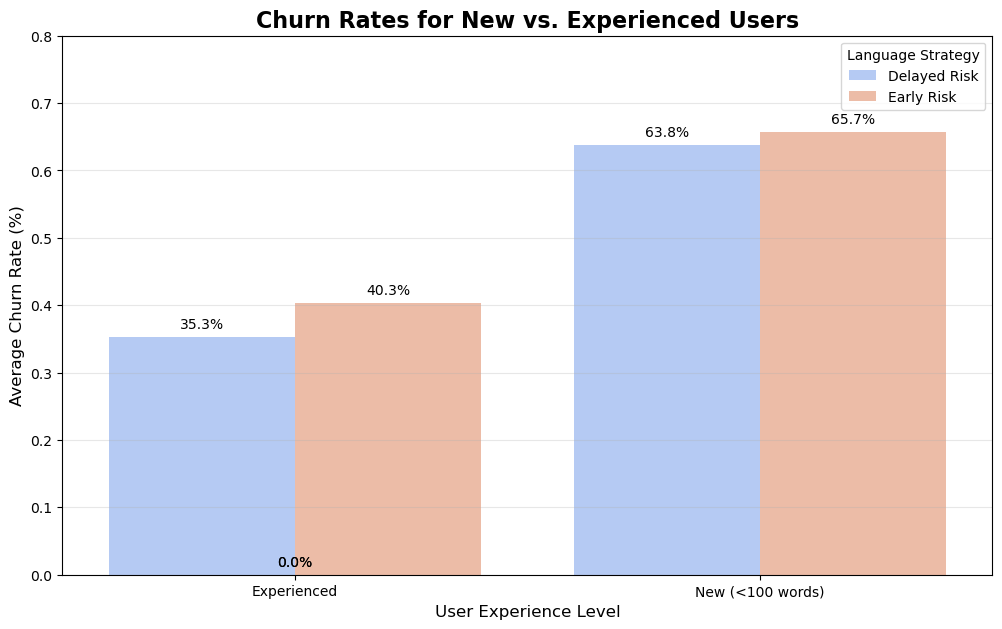

In [35]:

# 1. Define Groups based on your Aggression Report
gatekeepers = ['en', 'de']
easy = ['it']

# 2. Filter master_df for these specific languages
plot_df = master_df[master_df['primary_language'].isin(gatekeepers + easy)].copy()

# 3. Create User Experience Segments
plot_df['user_segment'] = plot_df['total_words_seen'].apply(
    lambda x: 'New (<100 words)' if x < 100 else 'Experienced'
)

# 4. Map Language to Type for the plot
type_map = {lang: 'Early Risk' if lang in gatekeepers else 'Delayed Risk' 
            for lang in gatekeepers + easy}
plot_df['language_type'] = plot_df['primary_language'].map(type_map)

# 5. Calculate Churn Rates
final_comparison = plot_df.groupby(['language_type', 'user_segment'])['is_churned'].mean().reset_index()

# 6. Plotting the results
plt.figure(figsize=(12, 7))
sns.barplot(data=final_comparison, x='user_segment', y='is_churned', hue='language_type', palette='coolwarm')

plt.title("Churn Rates for New vs. Experienced Users", fontsize=16, fontweight='bold')
plt.ylabel("Average Churn Rate (%)", fontsize=12)
plt.xlabel("User Experience Level", fontsize=12)
plt.ylim(0, 0.8)
plt.legend(title="Language Strategy")
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1%}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points')

plt.show()

In [36]:
from scipy.stats import chi2_contingency

# 1. Create a contingency table (Counts of Stayed vs Churned per POS)
contingency_table = pd.crosstab(df['broad_pos'], df['is_churned'])

# 2. Run the test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-value: {p:.4e}")

if p < 0.05:
    print("Result: Statistically Significant. POS has a real impact on churn.")
else:
    print("Result: Not Significant. The differences might be due to chance.")

Chi-Square Statistic: 34237.41
P-value: 0.0000e+00
Result: Statistically Significant. POS has a real impact on churn.


In [37]:
import statsmodels.api as sm

# 1. Pivot exposure counts per user to use as features
# We want to see how the 'dose' of each POS affects the outcome
user_pos_exposure = df.groupby(['user_id', 'broad_pos']).size().unstack(fill_value=0)
user_pos_exposure = user_pos_exposure.merge(master_df[['user_id', 'is_churned']], on='user_id')

# 2. Define X (POS counts) and y (Churn status)
X = user_pos_exposure.drop(columns=['user_id', 'is_churned'])
X = sm.add_constant(X) # Add intercept
y = user_pos_exposure['is_churned']

# 3. Fit the model
logit_model = sm.Logit(y, X).fit()

# 4. View the p-values for each POS
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.639773
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             is_churned   No. Observations:               115222
Model:                          Logit   Df Residuals:                   115209
Method:                           MLE   Df Model:                           12
Date:                Wed, 25 Feb 2026   Pseudo R-squ.:                 0.05706
Time:                        15:31:55   Log-Likelihood:                -73716.
converged:                       True   LL-Null:                       -78177.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.7145      0.008     93.776      0.000       0.700       0.729
Action Verbs     -0.

categories having positive coef, meaning every time a user encounters these words, their probability of churning increases significantly 
helper verbs most dangerous category
Linking Verbs statistically significant 
negative coef - Nouns (-0.0030) & Action Verbs  Users who engage with these feel a sense of progress. Even though they have high volume, they are "safe" words
Interjections (-0.0259) & Pronouns (-0.0111): These have the strongest "protective" effect. Users who master these are significantly more likely to stay. 
Articles have no statistical impact on churn in this model

In [38]:
from scipy.stats import f_oneway

# Compare Toxicity means across the top 3 learning languages
en_tox = df[df['learning_language'] == 'en']['word_toxicity']
es_tox = df[df['learning_language'] == 'es']['word_toxicity']
fr_tox = df[df['learning_language'] == 'fr']['word_toxicity']

f_stat, p_val = f_oneway(en_tox, es_tox, fr_tox)
print(f"ANOVA P-value: {p_val:.4e}")

ANOVA P-value: 0.0000e+00


In [44]:
# 1. Calculate stats by Language AND POS
lang_pos_story = df.groupby(['learning_language', 'broad_pos']).agg({
    'word_toxicity': 'mean',
    'is_churned': 'mean',
    'user_id': 'count'
}).reset_index()

# 2. Filter for significant volume to avoid noise (e.g., more than 500 interactions)
lang_pos_story = lang_pos_story[lang_pos_story['user_id'] > 500]

# 3. Create a 'Risk Score' (Toxicity * Churn Rate) to rank the pain points
lang_pos_story['risk_score'] = lang_pos_story['word_toxicity'] * lang_pos_story['is_churned']

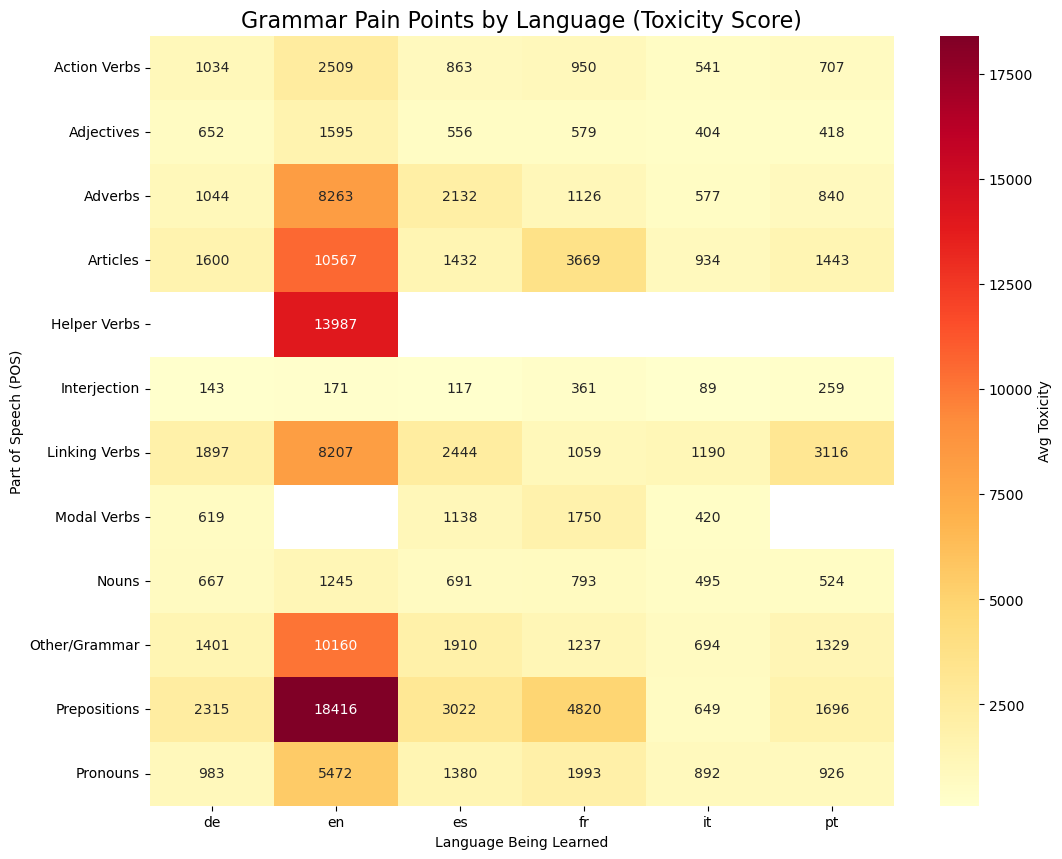

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot the data for the heatmap
pivot_tox = lang_pos_story.pivot_table(
    index='broad_pos', 
    columns='learning_language', 
    values='word_toxicity'
)

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_tox, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={'label': 'Avg Toxicity'})

plt.title("Grammar Pain Points by Language (Toxicity Score)", fontsize=16)
plt.xlabel("Language Being Learned")
plt.ylabel("Part of Speech (POS)")
plt.show()

English is the primary outlier where grammar complexity causes disproportionate friction compared to all other languages. 
In English, prepositions are notoriously idiomatic (e.g., depend on vs. wait for) and users are clearly struggling significantly more here than in any other language.
English is unique in its heavy reliance on auxiliary verbs (do, does, did, have). 
While French (fr) is generally "quieter" than English, it has a notable spike in Prepositions (4,820) and Articles (3,669).
the gendered articles (le/la) and combined prepositions (au/du) represent the first major "gatekeeper" hurdle before they reach conversational fluency.
The low toxicity in German Articles (1,600) compared to English (10,567) suggests that German learners might expect difficulty and are therefore less frustrated by errors, or the German curriculum is structured in a way that introduces these complexities more gradually.
Spanish, Italian, and Portuguese show very similar, stable patterns:

Linking Verbs: These show moderate toxicity across the board (pt: 3,116; es: 2,444). Mastering "to be" (ser vs. estar) remains a universal struggle for learners of Romance languages.

Action Verbs & Nouns are consistently the lowest toxicity areas across all languages. Users generally find learning "stuff" (nouns) and "actions" (verbs) satisfying and less prone to "toxic" frustration than learning "rules" (prepositions/articles).

Hence deciding when to open up with tougher categories becomes important!

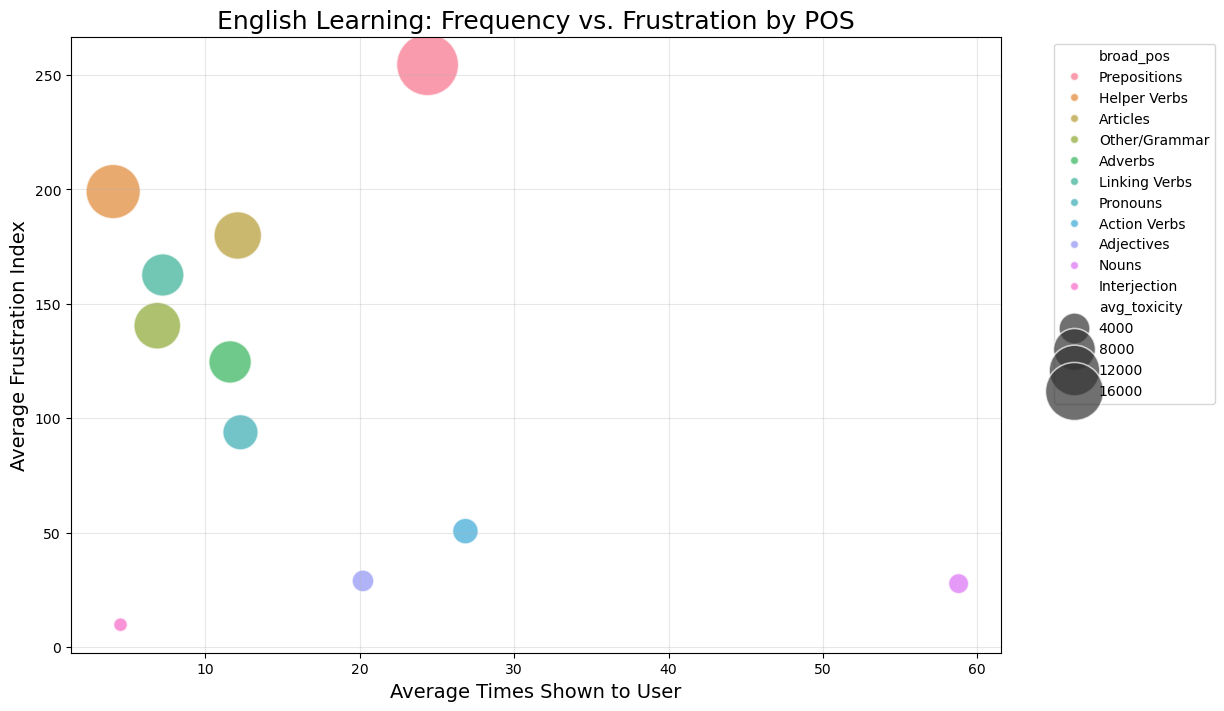

In [39]:
# 1. Group by Language and Category
pos_metrics = df.groupby(['learning_language', 'broad_pos']).agg(
    avg_frustration=('frustration_index', 'mean'),
    avg_toxicity=('word_toxicity', 'mean'),
    total_appearances=('lexeme_id', 'count'),
    unique_users=('user_id', 'nunique')
).reset_index()

# 2. Calculate "Exposure per User" 
# (How many times an average user sees this POS in their first few sessions)
pos_metrics['avg_times_shown'] = pos_metrics['total_appearances'] / pos_metrics['unique_users']

# 3. Sort by Toxicity to see the biggest offenders
pos_metrics = pos_metrics.sort_values(['learning_language', 'avg_toxicity'], ascending=[True, False])

# Filtering for English to keep the visual clean (you can swap 'en' for any lang)
en_pos = pos_metrics[pos_metrics['learning_language'] == 'en']

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=en_pos, 
    x='avg_times_shown', 
    y='avg_frustration', 
    size='avg_toxicity', 
    hue='broad_pos',
    sizes=(100, 2000),
    alpha=0.7
)

plt.title('English Learning: Frequency vs. Frustration by POS', fontsize=18)
plt.xlabel('Average Times Shown to User', fontsize=14)
plt.ylabel('Average Frustration Index', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\athul\AppData\Local\Temp\ipykernel_42556\1575877901.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_stats = master_df.groupby('word_bucket')['is_churned'].mean().reset_index()


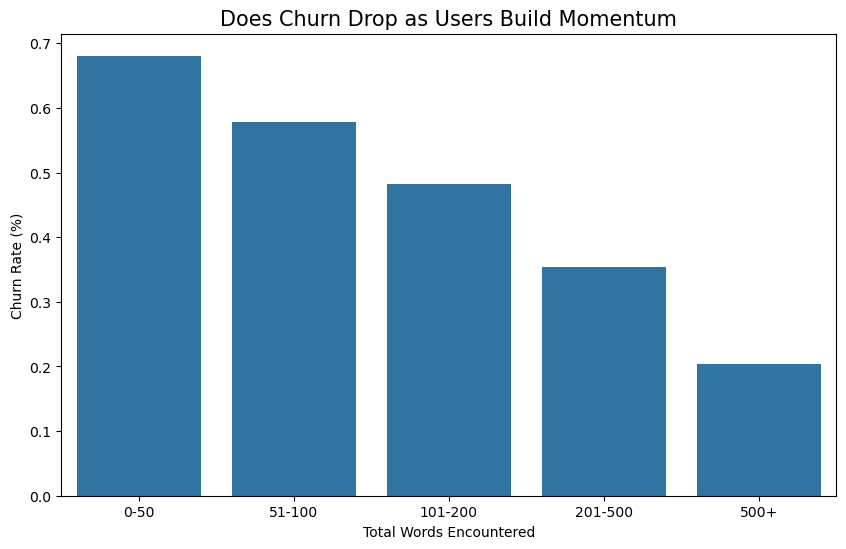

In [40]:
# Create word-count buckets
master_df['word_bucket'] = pd.cut(master_df['total_words_seen'], bins=[0, 50, 100, 200, 500, 1000], 
                                 labels=['0-50', '51-100', '101-200', '201-500', '500+'])

survival_stats = master_df.groupby('word_bucket')['is_churned'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=survival_stats, x='word_bucket', y='is_churned')
plt.title("Does Churn Drop as Users Build Momentum", fontsize=15)
plt.ylabel("Churn Rate (%)")
plt.xlabel("Total Words Encountered")
plt.show()

In [41]:
toxic_limit = df['frustration_index'].quantile(0.75)
df['is_toxic_interaction'] = df['frustration_index'] > toxic_limit

lang_toxicity = df.groupby('learning_language')['is_toxic_interaction'].mean().reset_index()
lang_toxicity.columns = ['learning_language', 'avg_toxic_load']

lang_churn = master_df.groupby('primary_language')['is_churned'].mean().reset_index()

story_df = lang_churn.merge(lang_toxicity, left_on='primary_language', right_on='learning_language')
print(story_df.sort_values('avg_toxic_load', ascending=False))

  primary_language  is_churned learning_language  avg_toxic_load
1               en    0.592398                en        0.295683
3               fr    0.594989                fr        0.282358
0               de    0.568120                de        0.204206
2               es    0.585644                es        0.200589
5               pt    0.572516                pt        0.189052
4               it    0.548356                it        0.176333


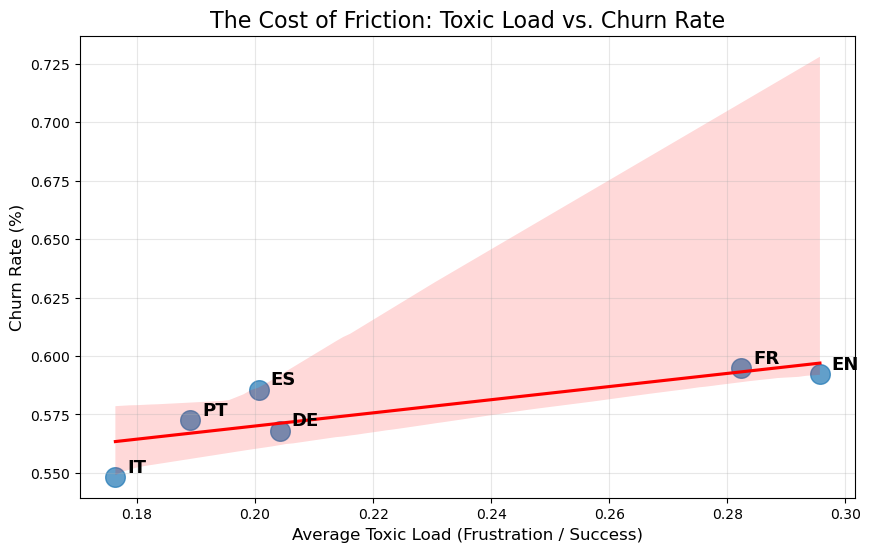

In [42]:
plt.figure(figsize=(10, 6))

# Create the scatter with a regression line to show the trend
sns.regplot(data=story_df, x='avg_toxic_load', y='is_churned', 
            scatter_kws={'s': 200, 'alpha': 0.7}, line_kws={'color': 'red'})

# Annotate the languages
for i, txt in enumerate(story_df['primary_language']):
    plt.annotate(txt.upper(), (story_df['avg_toxic_load'].iloc[i] + 0.002, 
                               story_df['is_churned'].iloc[i] + 0.002), 
                 fontsize=13, fontweight='bold')

plt.title("The Cost of Friction: Toxic Load vs. Churn Rate", fontsize=16)
plt.xlabel("Average Toxic Load (Frustration / Success)", fontsize=12)
plt.ylabel("Churn Rate (%)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

English & French - highest avg_toxic_load and the highest churn rates 
high density of difficult words and early grammar spikes is likely creating a burnout that pushes users out

Italian has the lowest toxic load and lowest churn by keeping the "Grace Period" long and the toxicity low, Italian is effectively "protecting" its users while they build a habit.

German & Portuguese have moderate toxicity but relatively controlled churn.
while the curriculum might be aggressive, the users choosing these languages might have higher Intrinsic Motivation 